# Project Final Report

### Due: Midnight on April 27 (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **three components**:

---

### 1. Final Report Notebook [40 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

- **Part A**: Select the single best model from your Milestone 2 experiments. Now that you’ve finalized your model, revisit your decisions from Milestones 1 and 2. Are there any steps you would change—such as cleaning, feature engineering, or model evaluation—given what you now know?

- **Part B**: Write a technical report following standard conventions, for example:
  - [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
  - [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
  - The Checklist given in this week's Blackboard Lesson (essentially the same as in HOML).
    
  Your audience here is technically literate but unfamiliar with your work—like your manager or other data scientists. Be clear, precise, and include both code (for illustration), charts/plots/illustrations, and explanation of what you discovered and your reasoning process. 

The idea here is that Part A would be a repository of the most important code, for further work to come, and Part B is
the technical report which summarizes your project for the data science group at your company. Do NOT assume that readers of Part B are intimately familiar with Part A; provide code for illustration as needed, but not to run.

Submit this notebook as a group via your team leader’s Gradescope account.

---

### 2. PowerPoint Presentation [10 pts]

Create a 10–15 minute presentation designed for a general audience (e.g., sales or marketing team).

- Prepare 8–12 slides, following the general outline of the sections of Part B. 
- Focus on storytelling, visuals (plots and illustrations), and clear, simplified language. No code!
- Use any presentation tool you like, but upload a PDF version.
- List all team members on the first slide.

Submit as a group via your team leader’s Gradescope account.

---

### 3. Individual Assessment

Each team member must complete the Individual Assessment Form (same as in Milestone 1), sign it, and upload it via their own Gradescope account.

---

## Submission Checklist

-  Final Report Notebook — Team leader submission
-  PDF Slides — Team leader submission
-  Individual Assessment Form — Each member submits their own


## Part A: Final Model and Design Reassessment [10 pts]

In this part, you will finalize your best-performing model and revisit earlier decisions to determine if any should be revised in light of your complete modeling workflow. You’ll also consolidate and present the key code used to run your model on the preprocessed dataset, with thoughtful documentation of your reasoning.

**Requirements:**

- Reconsider **at least one decision from Milestone 1** (e.g., preprocessing, feature engineering, or encoding). Explain whether you would keep or revise that decision now that you know which model performs best. Justify your reasoning.
  
- Reconsider **at least one decision from Milestone 2** (e.g., model evaluation, cross-validation strategy, or feature selection). Again, explain whether you would keep or revise your original decision, and why.

- Below, include all code necessary to **run your final model** on the processed dataset. This section should be a clean, readable summary of the most important steps from Milestones 1 and 2, adapted as needed to fit your final model choice and your reconsiderations as just described. 

- Use Markdown cells and inline comments to explain the structure of the code clearly but concisely. The goal is to make your reasoning and process easy to follow for instructors and reviewers.

> Remember: You are not required to change your earlier choices, but you *are* required to reflect on them and justify your final decisions.


In [28]:
# Add as many code cells as you need

In [29]:
# =============================
# Useful Imports (overinclusive to hopefully avoid any issues further down)
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
import kagglehub
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

In [30]:
# Data load in from external source if not already present in your current working directory
url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [31]:
# Load in data from local directory (comment out path you are not using)

#df = pd.read_csv("/Users/ez873/Documents/Module-3-Assignments-main/zillow_dataset.csv") #Emma

df = pd.read_csv("zillow_dataset.csv") # Hailey

In [32]:
# Review basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [33]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [34]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

This dataset contains 77613 rows (entries) and 55 columns (variables). Some parcel IDs are duplicated (n = 77613 vs nunique = 77414) and will need to be evaluated. This likely indicates multiple sales of the same properties, so we will want to keep the most recent examples to be as accurate as possible to today's market. There are also only 77578 of the 77613 that have values for our target (assessed tax value, variable name "taxvaluedollarcnt"), so we will need to remove the instances with missing or null target values. 

In [35]:
# Feature level EDA

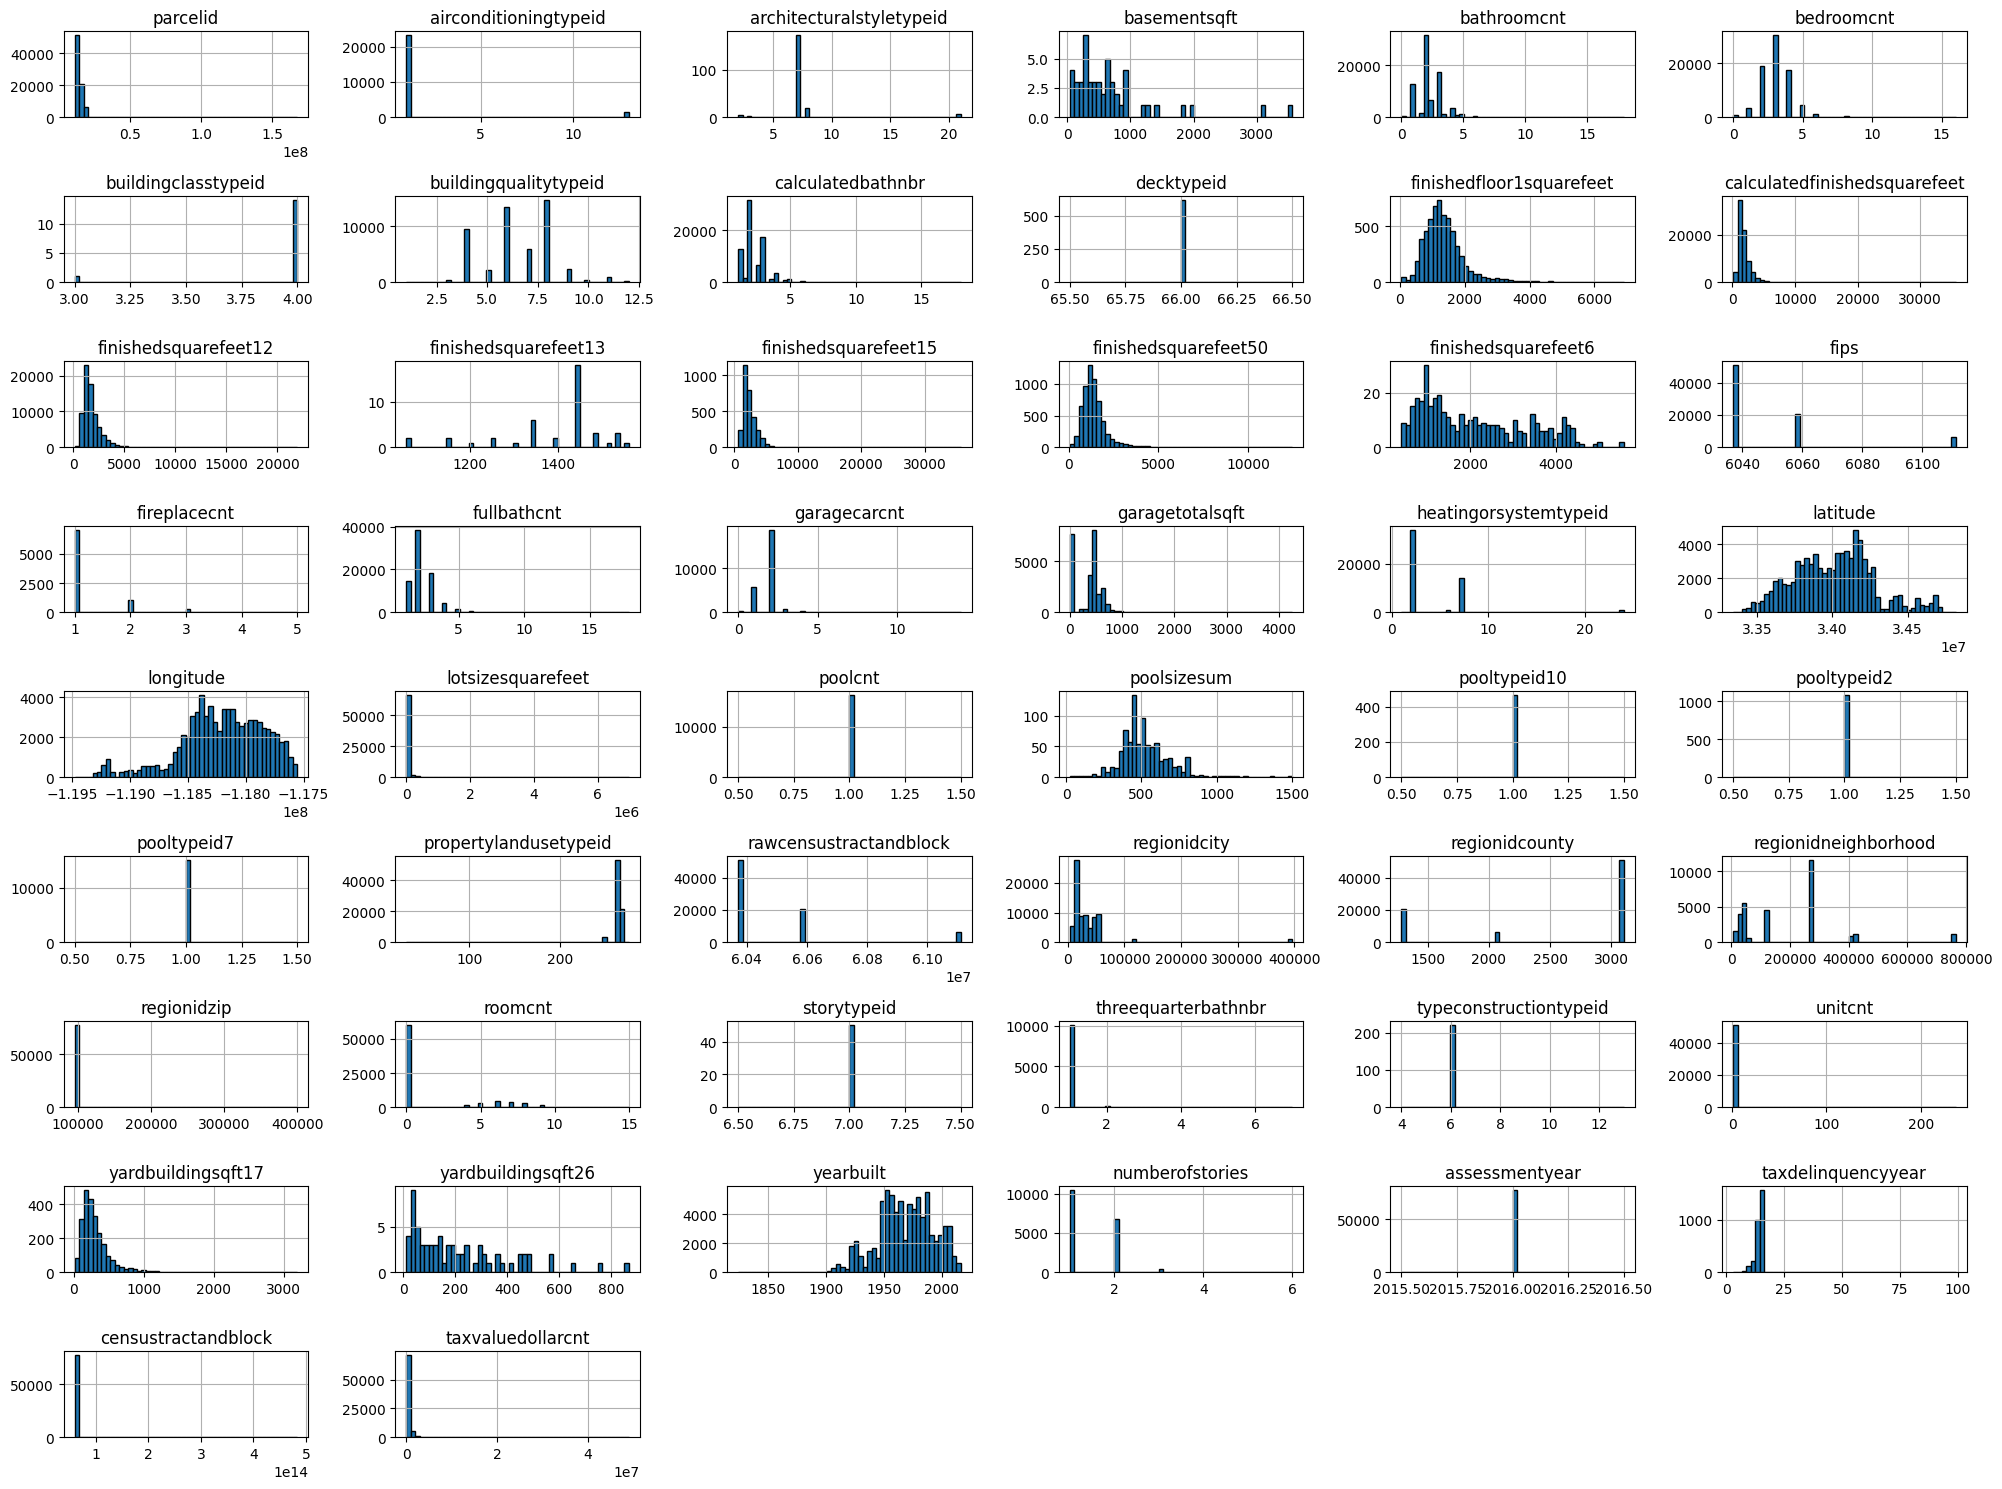

In [36]:
# Histograms of all features to explore distributions and potential features of interest
df.hist(figsize=(20, 15), layout=(-1, 6), bins=50, edgecolor='black')

plt.tight_layout()
plt.show()

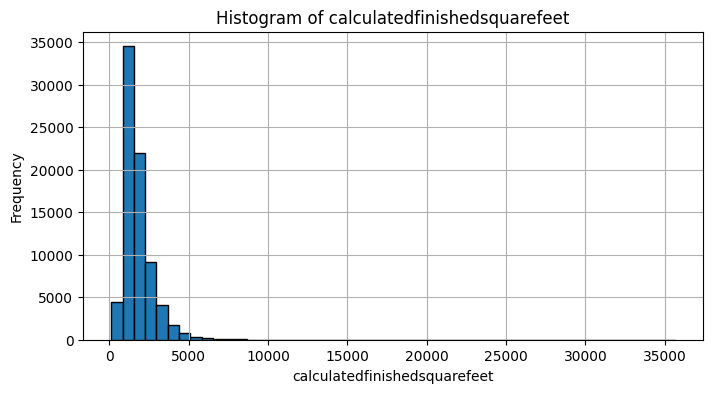

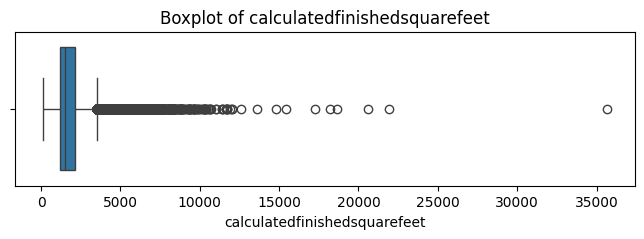

In [37]:
# Feature one: Calculated finished square feet
# This variable is interesting because it is likely to be correlated with property value and the histogram shows a decent amount 
# of spread that will hopefully capture meaningful variance in the target. 

# Specify variable and target
feature = 'calculatedfinishedsquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Here we have a right-skewed distribution with outliers well outside the upper IQR bound.
# Some outliers are very high, fairly spare, and should likely drive results. 

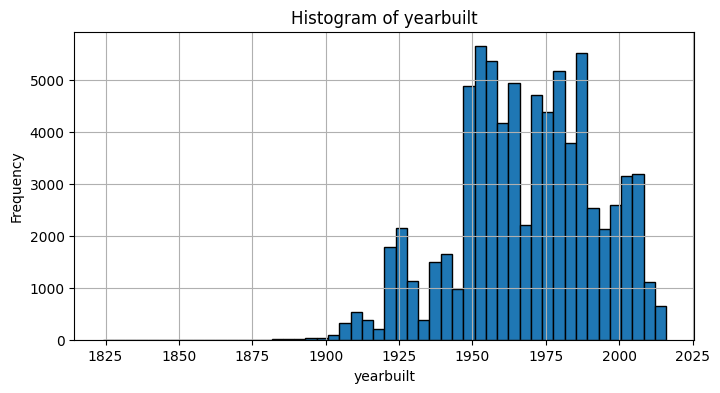

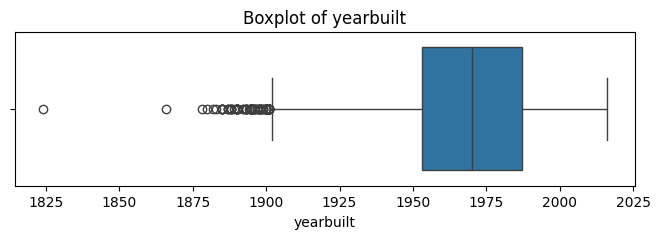

In [38]:
# Feature two: Year built
# This variable is interesting becasue it has a flatter and broader distribution than most others. It also isn't associated with inherent
# value but will indicate more about whether houses from a certain time period are more valuable than others. 

# Specify variable and target
feature = 'yearbuilt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=50, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Year built is a left-skewed distribution with a handful of early years built. There are a couple of outliers that would skew results in 
# analyses that consider the year built as a numeric variable, but in most use cases this should be categorical.

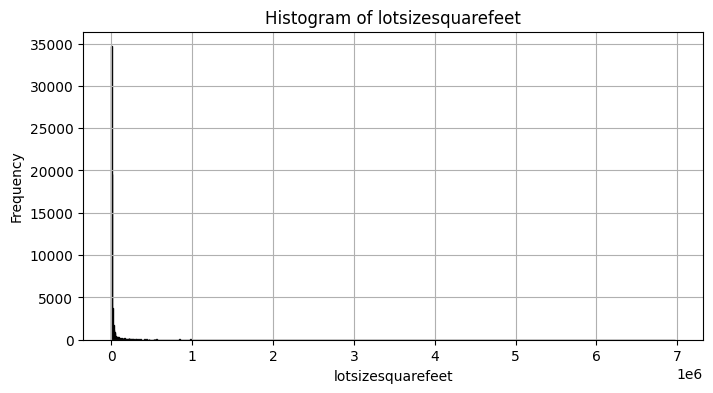

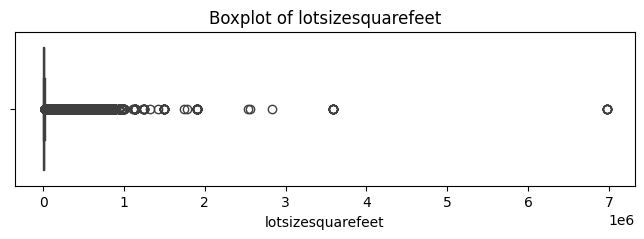

In [39]:
# Feature three: Lot size square feet
# Generally speaking, you pay more to have more so larger lot size is likely to be associated with higher value. It is also interesting
# in that most of the data falls within a narrow range. 

# Specify variable and target
feature = 'lotsizesquarefeet'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[feature].dropna(), bins=1000, edgecolor='black')
plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[feature])
plt.title(f'Boxplot of {feature}')
plt.show()

# Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately 
# those above 1e6) that are sparse enough that they may drive/bias results depending on the analysis.

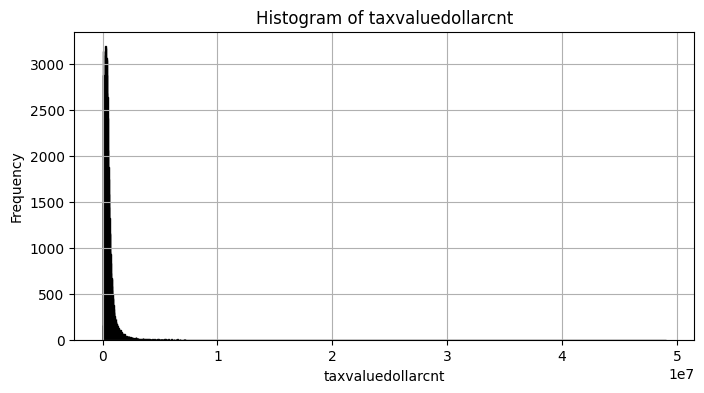

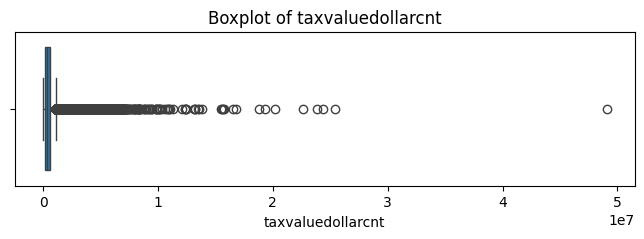

In [40]:
# Target: Tax value dollar cent

# Specify target
target = 'taxvaluedollarcnt'

# 1. Histogram
plt.figure(figsize=(8, 4))
plt.hist(df[target].dropna(), bins=2000, edgecolor='black')
plt.title(f'Histogram of {target}')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df[target])
plt.title(f'Boxplot of {target}')
plt.show()

# The overall target distribution is most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very 
# narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems 
# reasonable as does the overall distribution. 

The features we selected to focus on are calculated finished square feet, year built, and lot size sqare feet. Calculated finished square feet is interesting because it is likely to be correlated with property value and the histogram shows a decent amount of spread that will hopefully capture meaningful variance in the target. The histogram shows a right-skewed distribution with outliers well outside the upper IQR bound. Some outliers are very high, fairly spare, and are likely drive results, depending on which model we use. We selected year built because it has a flatter and broader distribution than most other variables. It also isn't associated with inherent value but can inform us on whether houses from a certain time period are deemed more valuable than others. The histogram shows a left-skewed distribution with a handful of early years built. There are again a couple of outliers that would skew results in analyses that consider the year built as a numeric variable, but in most use cases this should be used as categorical. Generally speaking, you pay more to have more so we selected lot size thinking it is likely to be highly associated with value. It is also interesting in that most of the data falls within a narrow range. Lot size has a right-skew distribution with a narrow IQR and a long tail of upper values. There are a few outlier values (approximately those above 1e6) that are sparse enough that they may drive/bias results depending on the analysis. The overall target distribution looks most similar to the lot size distribution, demonstrating a right-skew with a long tail and a very narrow IQR. Here too we see upper outliers that become increasingly sparse past about 1.2e7. That said, the range of values seems reasonable as does the overall distribution.

WHAT WE ARE DOING DIFFERENTLY
- Initially missed the duplicated IDs, so we need to account for them this time around.
- In Milestone One, our threshold for removing variables with "too many null values" was likely too conservative at 20% null, allowing for relatively few variables to make the cut.
- We are also cleaning our dataset by removing too many null values first and then removing variables from there. 

In [41]:
# This function will list how many nulls occur in which features

def show_null_counts_features(df_input):
    # Count nulls and percentages
    count_nulls = df_input.isnull().sum()
    df_nulls = (df_input.isnull().mean() * 100).round(2)
    
    # Identify variable types
    feature_types = df_input.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')
    
    # Construct dataframe of missing data
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values, 
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)

    # Display summary
    print(f'The dataset contains {len(df_input)} samples.\n')

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
    else:
        print('Feature Name    # Nulls      Null %    Type')
        print('------------    -------      ------    ----')
        for _, row in missing_data.iterrows():
            print(f"{row['Feature']:<15} {row['# Null Values']:<12} {row['Null %']:.2f}%   {row['Type']}")

In [42]:
# Initialize a copy of our dataset for cleaning
df_clean = df.copy()

In [43]:
# Remove all rows without a target value ('taxvaluedollarcnt')
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt']).copy()

#show_null_counts_features(df_clean)

In [44]:
# Isolate rows with duplicate IDs
duplicate_rows = df[df.duplicated(subset='parcelid', keep=False)]

# Print all rows with duplicate IDs
#print(duplicate_rows)

In [45]:
# Drop one instance of duplicated rows
df_clean.drop_duplicates(subset='parcelid', keep='last')

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,10833991,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1980.0,NaN,NaN,2016.0,NaN,NaN,6.037132e+13,379000.0
77609,11000655,NaN,NaN,NaN,2.0,2.0,NaN,6.0,2.0,NaN,...,NaN,NaN,1940.0,NaN,NaN,2016.0,NaN,NaN,6.037101e+13,354621.0
77610,17239384,NaN,NaN,NaN,2.0,4.0,NaN,NaN,2.0,NaN,...,656.0,NaN,1964.0,1.0,NaN,2016.0,NaN,NaN,6.111008e+13,67205.0
77611,12773139,1.0,NaN,NaN,1.0,3.0,NaN,4.0,1.0,NaN,...,NaN,NaN,1954.0,NaN,NaN,2016.0,NaN,NaN,6.037434e+13,49546.0


In [46]:
#print(df['propertyzoningdesc'].unique())

In [47]:
max_nulls = 0.6*len(df_clean)      
print(max_nulls)

46546.799999999996


In [48]:
#show_null_counts_features(df_clean)

In [60]:
# The max_nulls limit here is currently set to 60%. Any variable with non-null values for less than 20% of instances will be dropped.
max_nulls = 0.6*len(df_clean)      # We will drop any features with more than max_nulls missing values

# Drop the columns where null count exceeds max_nulls

df_clean2 = df_clean.drop(columns=df_clean.columns[df_clean.isnull().sum() > max_nulls]).copy()

# Uncomment to verify they were removed

show_null_counts_features(df_clean2)

The dataset contains 77578 samples.

Feature Name    # Nulls      Null %    Type
------------    -------      ------    ----
heatingorsystemtypeid 28007        36.10%   Numeric
buildingqualitytypeid 27769        35.79%   Numeric
propertyzoningdesc 27102        34.94%   Categorical
unitcnt         26875        34.64%   Numeric
lotsizesquarefeet 8258         10.64%   Numeric
finishedsquarefeet12 3656         4.71%   Numeric
regionidcity    1472         1.90%   Numeric
calculatedbathnbr 616          0.79%   Numeric
fullbathcnt     616          0.79%   Numeric
yearbuilt       270          0.35%   Numeric
censustractandblock 247          0.32%   Numeric
calculatedfinishedsquarefeet 201          0.26%   Numeric
regionidzip     50           0.06%   Numeric


We do not need an ID column as they are randomly assigned and should not provide any information on the variance. Assessment year is the same or NaN for all and can also be removed. Deck type and text-based variables are also not useful for the regression task.

In [61]:
# Remove irrelevant features
cols_to_drop = ['parcelid', 'assessmentyear', 'decktypeid', 'propertyzoningdesc','longitude','latitude']
existing_cols = [col for col in cols_to_drop if col in df_clean2.columns]

df_clean2 = df_clean2.drop(columns=existing_cols)

Next we will impute values for the remaining nulls.

In [68]:
print(df_clean2.columns.tolist())

['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertycountylandusecode', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock', 'taxvaluedollarcnt']


In [69]:
# Correctly classify categorical variables for imputing
cols_to_convert = ['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid','buildingqualitytypeid','fireplaceflag',
                   'taxdelinquencyflag','taxdelinquencyyear']
df_clean2[cols_to_convert] = df_clean2[cols_to_convert].astype('category')

KeyError: "['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear'] not in index"

In [70]:
cols_to_convert = ['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid',
                   'buildingqualitytypeid', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']

existing_cols = [col for col in cols_to_convert if col in df_clean2.columns]
df_clean2[existing_cols] = df_clean2[existing_cols].astype('category')


In [71]:
# Identify categorical and numeric features
categorical_features = df_clean2.select_dtypes(exclude=['number']).columns.tolist()
numeric_features     = df_clean2.select_dtypes(include=['number']).columns.tolist()

# First make a copy of the cleaned dataset, call it df_imputed
df_imputed = df_clean2.copy()

# Impute numeric columns (using the median)
num_imputer = SimpleImputer(strategy='median')
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

In [63]:
# Impute numeric columns (using the median)
cat_imputer = SimpleImputer(strategy='most_frequent')
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

In [64]:
# Verify: There should be no null values
show_null_counts_features(df_imputed)

The dataset contains 77578 samples.

There are no null values in the dataset!


                         Feature   F-Statistic        P-Value
4           finishedsquarefeet12  42035.783370   0.000000e+00
3   calculatedfinishedsquarefeet  39046.634476   0.000000e+00
2              calculatedbathnbr  22820.073732   0.000000e+00
6                    fullbathcnt  21427.245430   0.000000e+00
0                    bathroomcnt  20937.303354   0.000000e+00
1                     bedroomcnt   4713.271746   0.000000e+00
16                     yearbuilt   1105.190813  1.222386e-240
7          heatingorsystemtypeid    827.393946  5.369273e-181
12                regionidcounty    119.797050   7.344536e-28
9          propertylandusetypeid    100.278591   1.368452e-23
11                  regionidcity     45.726773   1.369107e-11
8              lotsizesquarefeet     29.371450   5.992897e-08
13                   regionidzip     16.358368   5.247483e-05
5                           fips      3.036407   8.141990e-02
10        rawcensustractandblock      2.470593   1.159982e-01
15      

/tmp/ipykernel_6436/342108438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')


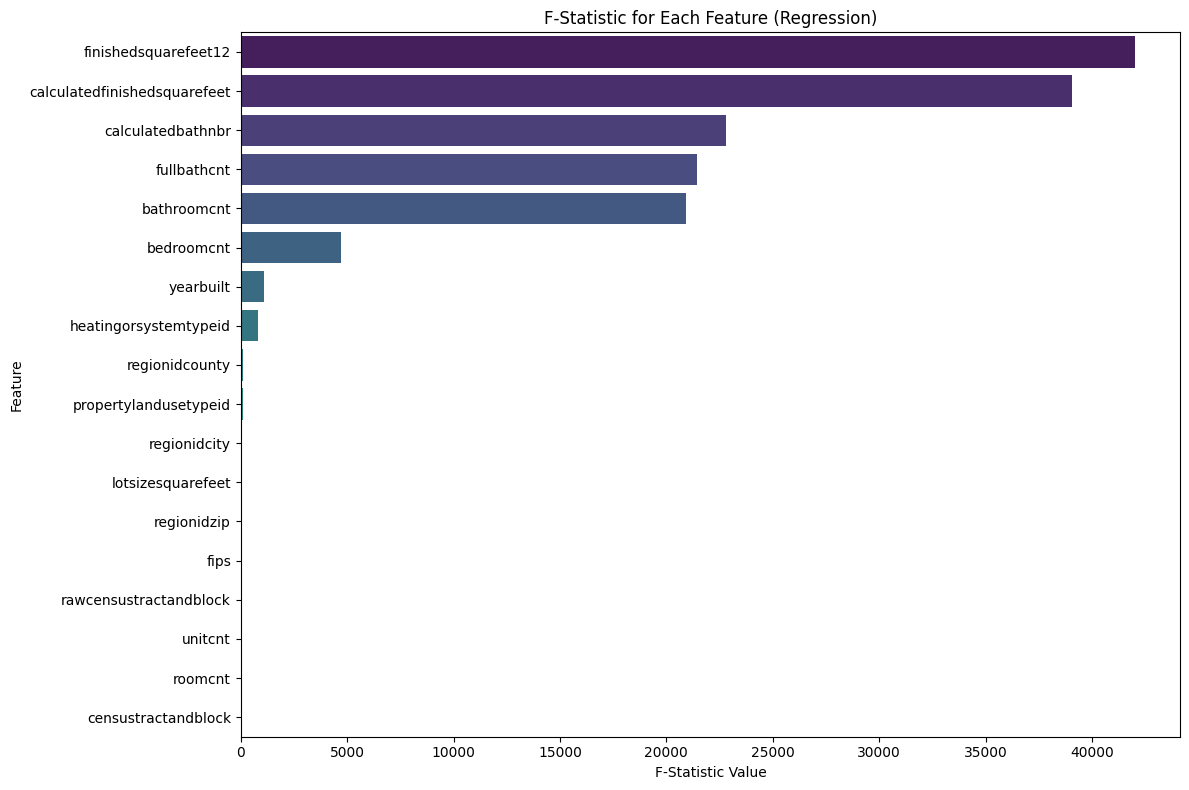

In [65]:
# Compute the F-statistic for all features for a good view of the relationships

from sklearn.feature_selection import f_regression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows with nulls for this analysis
X = df_imputed.drop('taxvaluedollarcnt', axis=1)  
y = df_imputed['taxvaluedollarcnt']

X_numeric = X.select_dtypes(include=[np.number])

# Compute F-statistics for regression
f_values, p_values = f_regression(X_numeric, y)

# Create DataFrame of results
f_stat_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F-Statistic': f_values,
    'P-Value': p_values
}).sort_values(by='F-Statistic', ascending=False)

# Display top results
print(f_stat_df)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='F-Statistic', y='Feature', data=f_stat_df, palette='viridis')
plt.title('F-Statistic for Each Feature (Regression)')
plt.xlabel('F-Statistic Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [66]:
# Investigate forward feature selection
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_imputed.drop('taxvaluedollarcnt', axis=1) 
y = df_imputed['taxvaluedollarcnt']

model = LinearRegression()

selected_features = []
remaining_features = list(X_numeric.columns)

best_score = np.inf  

while remaining_features:
    scores = []
    
    for feature in remaining_features:
        features_to_test = selected_features + [feature]
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    scores.sort()
    
    best_score, best_feature = scores[0]
    
    selected_features.append(best_feature)
    
    remaining_features.remove(best_feature)

    print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")

print("Final selected features:", selected_features)


Selected Features: ['censustractandblock'] with Negative MSE: -428289490246.4297
Selected Features: ['censustractandblock', 'fips'] with Negative MSE: -1734422925600.1604
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt'] with Negative MSE: -2311484912883.0698
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt', 'roomcnt'] with Negative MSE: -2356441645294.9375
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt', 'roomcnt', 'propertylandusetypeid'] with Negative MSE: -2385107643344.3193
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt', 'roomcnt', 'propertylandusetypeid', 'unitcnt'] with Negative MSE: -2391939246577.1948
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt', 'roomcnt', 'propertylandusetypeid', 'unitcnt', 'regionidzip'] with Negative MSE: -2394437259182.9873
Selected Features: ['censustractandblock', 'fips', 'bedroomcnt', 'roomcnt', 'propertylandusetypeid', 'unitcnt', 'regionidzip', 'heatingorsystemtypeid'] w

In [67]:
# Investigate backward feature selection

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_imputed.drop('taxvaluedollarcnt', axis=1) 
y = df_imputed['taxvaluedollarcnt']

model = LinearRegression()

selected_features = list(X_numeric.columns)
remaining_features = selected_features.copy()

best_score = np.inf  

while len(remaining_features) > 0:
    scores = []
    
    for feature in remaining_features:
        features_to_test = [f for f in selected_features if f != feature]
        
        if len(features_to_test) == 0:
            continue
        
        score = cross_val_score(model, X[features_to_test], y, cv=5, scoring='neg_mean_squared_error').mean()
        
        scores.append((score, feature))
    
    if scores:
        scores.sort()
        best_score, worst_feature = scores[0]
        
        selected_features.remove(worst_feature)
        remaining_features.remove(worst_feature)

        print(f"Selected Features: {selected_features} with Negative MSE: {best_score:.4f}")
    else:
        break

print("Final selected features:", selected_features)


Selected Features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock'] with Negative MSE: -293933655792.2900
Selected Features: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandblock'] with Negative MSE: -440684254246.9796
Selected Features: ['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcity', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'censustractandb

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# sweep_params for train only

def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train,
                    y_train          = y_train,
                    verbose          = True,
                    show_rmse        = True,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 10):
    
    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_mses, std_cvs, train_mses = [], [], []
    no_improve_count = 0
    best_mse = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        # Remove MSE_found if present, just in case
        P_temp.pop('MSE_found', None)
        
        cv_mse, std_cv, train_mse = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_mses.append(cv_mse)
        std_cvs.append(std_cv)
        train_mses.append(train_mse)
        
        # Early-stopping logic
        if cv_mse < best_mse - delta:
            best_mse = cv_mse
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break
    
    # Identify best parameter
    min_cv_mse = min(cv_mses)
    min_index = cv_mses.index(min_cv_mse)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MSE_found'] = min_cv_mse
    
    if verbose:
        # Prepare for plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        
        # We only need as many parameter values as we actually computed
        partial_param_list = parameter_list[:len(cv_mses)]
        
        # Check if our parameter list is Boolean so we can label accordingly
        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            # Convert booleans to integer indices for plotting
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            # Treat numeric or other types as-is
            x_vals = partial_param_list
            x_labels = partial_param_list
        
        error_name = 'RMSE' if show_rmse else 'MSE'
        
        # ----- First plot: (R)MSE -----
        ax1.set_title(f"{error_name} vs {param}")
        
        # Apply dollar formatting ONLY if we're showing RMSE
        if show_rmse:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
        
        # Plot lines
        ax1.plot(x_vals,
                 np.sqrt(cv_mses) if show_rmse else cv_mses,
                 marker='.', label=f"CV {error_name}", color='blue')
        ax1.plot(x_vals,
                 np.sqrt(train_mses) if show_rmse else train_mses,
                 marker='.', label=f"Train {error_name}", color='green')
        ax1.scatter([x_vals[min_index]],
                    [np.sqrt(min_cv_mse) if show_rmse else min_cv_mse],
                    marker='x', label=f"Best CV {error_name}", color='red')
        
        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()
        
        # ----- Second plot: CV Std Dev -----
        ax2.set_title(f"CV Standard Deviation vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label=f"CV {error_name} Std", color='blue')
        ax2.set_xlabel(param)
        ax2.set_ylabel("Standard Deviation")
        ax2.legend()
        ax2.grid(alpha=0.5)
        
        # If we are using boolean x-values, set custom ticks
        if is_boolean:
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels)
        
        plt.tight_layout()
        plt.show()
        
        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))
    
    return Parameters


In [ ]:
# Change different combo of variables based on above (rerun with bagging)
    #
# RMSE is good for bagging
# If time and computational cost are issues, consider switching from RepeatedKFold to KFold with fewer splits or reducing the number of repeats in RepeatedKFold - see answer in milestone 3



In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create interaction terms
data['interaction1'] = data['finishedsquarefeet12'] * data['bedroomcnt']
data['interaction2'] = data['calculatedfinishedsquarefeet'] * data['bathroomcnt']

# Select the features including interaction terms
features = ['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'fullbathcnt', 
            'bathroomcnt', 'bedroomcnt', 'yearbuilt', 'interaction1', 'interaction2']

# Split data into training and testing
X = data[features]
y = data['target_variable']  # Replace with your target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Bagging Regressor with Decision Tree as base model
bagging_model = BaggingRegressor(base_estimator=DecisionTreeRegressor(max_depth=5), 
                                 n_estimators=100, random_state=42)

bagging_model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = bagging_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


**And don't forget about commentary cells!**

## Part B: Final Data Science Project Report Assignment [30 pts]

This final report is the culmination of your semester-long Data Science project, building upon the exploratory analyses and modeling milestones you've already completed. Your report should clearly communicate your findings, analysis approach, and conclusions to a technical audience. The following structure and guidelines, informed by best practices, will help you prepare a professional and comprehensive document.

### Required Sections

Your report must include the following sections:


#### 1. Executive Summary (Abstract) [2 pts]
- Brief overview of the entire project (150–200 words)
- Clearly state the objective, approach, and key findings

#### 2. Introduction [2 pts]
- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement)
- Clearly state the objectives and goals of your analysis

Note: You may imaginatively consider this project as taking place in a real estate company with a small data science group in-house, and write your introduction from this point of view (don't worry about verisimilitude to an actual company!).  

#### 3. Data Description [2 pts]
- Describe the source of your dataset (described in Milestone 1)
- Clearly state the characteristics of your data (size, types of features, missing values, target, etc.)

#### 4. Methodology (What you did, and why)  [12 pts]

**Focus this section entirely on the steps you took and your reasoning behind them. Emphasize the process and decision-making, not the results themselves**

- Describe your analytical framework 
  - Use of validation curves to see the effect of various hyperparameter choices, and
  - Choice of RMSE as primary error metric
- Clearly outline your data cleaning and preprocessing steps
  - Describe what issues you encountered in the raw data and how you addressed them.
  - Mention any key decisions (e.g., removing samples with too many missing values).
  - What worked and what didn't work?
- Describe your feature engineering approach
  - Explain any transformations, combinations, or derived features.
  - Discuss why certain features were chosen or created, even if they were later discarded.
  - What worked and what didn't work?
- Detail your model selection process 
  - Outline the models you experimented with and why.
  - Discuss how you evaluated generalization (e.g., cross-validation, shape and relationships of plots).
  - Mention how you tuned hyperparameters or selected the final model.



#### 5. Results and Evaluation (What you found, and how well it worked) [10 pts]

**Focus purely on outcomes, with metrics, visuals, and insights. This is where you present evidence to support your conclusions.**

- Provide a clear and detailed narrative of your analysis and reasoning using the analytical approach described in (4). 
- Discuss model performance metrics and results (RMSE, R2, etc.)
- **Include relevant visualizations (graphs, charts, tables) with appropriate labels and captions**
- Error analysis
  - Highlight specific patterns of error, outliers, or questionable features.
  - Note anything surprising or worth improving in future iterations.


#### 6. Conclusion [2 pts]
- Clearly state your main findings and how they address your original objectives
- Highlight the business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions